<a href="https://colab.research.google.com/github/Akashh0/Lung-Cancer/blob/Team3/Segmentation_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [24]:
!ls "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/"

ground_truth_masks_subset1  processed_data_subset1


In [4]:
# Install a specific, compatible version of MONAI
!pip install --force-reinstall "monai[tqdm]==1.3.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 965.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6

In [2]:
import monai

# Now you can access the library's attributes
print(monai.__version__)

1.5.1


In [33]:
from monai.networks.nets import UNETR

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import random
from tqdm import tqdm # For a nice progress bar

# ===================================================================
# 1. THE DATASET CLASS (No changes needed)
# ===================================================================
class LungNoduleDataset(Dataset):
    """
    PyTorch Dataset for loading 3D lung scans.
    MODIFIED to extract random 3D patches to avoid memory errors.
    """
    def __init__(self, data_dir, masks_dir, patch_size=(96, 96, 96)):
        self.data_dir = data_dir
        self.masks_dir = masks_dir
        self.patch_size = patch_size

        mask_uids = {f.replace('_nodule_mask.npy', '') for f in os.listdir(masks_dir)}
        scan_files = {f.replace('_processed_lung.npy', '') for f in os.listdir(data_dir)}

        self.available_uids = sorted(list(mask_uids.intersection(scan_files)))

        print(f"Found {len(self.available_uids)} scans with corresponding nodule masks.")

    def __len__(self):
        return len(self.available_uids)

    def __getitem__(self, idx):
        uid = self.available_uids[idx]

        scan_path = os.path.join(self.data_dir, f"{uid}_processed_lung.npy")
        mask_path = os.path.join(self.masks_dir, f"{uid}_nodule_mask.npy")

        # Load the full 3D arrays
        try:
            scan = np.load(scan_path)
            mask = np.load(mask_path)
        except Exception as e:
            print(f"Error loading files for UID {uid}: {e}")
            print(f"Scan path: {scan_path}")
            print(f"Mask path: {mask_path}")
            # Re-raise the exception after printing info, or handle it as appropriate
            raise

        # --- Start of Patching Logic ---
        depth, height, width = scan.shape
        pd, ph, pw = self.patch_size

        # Check if the scan is smaller than the patch size in any dimension
        if depth < pd or height < ph or width < pw:
            print(f"Warning: Scan {uid} with shape {scan.shape} is smaller than patch size {self.patch_size}. Skipping.")
            # Return None or raise an error, depending on desired behavior
            # Returning None requires custom handling in the DataLoader collation
            # For simplicity here, we'll raise an error, but in a real scenario
            # you might want to filter these out in __init__ or handle collation.
            raise ValueError(f"Scan {uid} is too small for patching.")


        # Get random coordinates for the top-left corner of the patch
        z = random.randint(0, depth - pd)
        y = random.randint(0, height - ph)
        x = random.randint(0, width - pw)

        # Extract the patch
        scan_patch = scan[z:z+pd, y:y+ph, x:x+pw]
        mask_patch = mask[z:z+pd, y:y+ph, x:x+pw]

        # Convert the patch arrays to PyTorch tensors and add a channel dimension
        scan_tensor = torch.from_numpy(scan_patch).unsqueeze(0).float()
        mask_tensor = torch.from_numpy(mask_patch).unsqueeze(0).float()

        return scan_tensor, mask_tensor

# ===================================================================
# 2. THE MODEL ARCHITECTURE (UPDATED to UNETR)
# ===================================================================
def get_unetr_model(patch_size, device):
    """
    Initializes the UNETR model with the required parameters.
    """
    # <-- UPDATED MODEL: Use UNETR with its standard parameters
    model = UNETR(
        in_channels=1,
        out_channels=1,
        img_size=patch_size,
        feature_size=16,
        hidden_size=768,
        mlp_dim=3072,
        num_heads=12,
        norm_name="instance",
    ).to(device)
    return model

# ===================================================================
# 3. THE TRAINING LOOP (Minor text changes for clarity)
# ===================================================================
if __name__ == '__main__':
    # --- Training Configuration ---
    # !!! IMPORTANT: Update these paths to match your Google Drive structure !!!
    processed_data_dir = "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/processed_data_subset1/"
    ground_truth_masks_dir = "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/ground_truth_masks_subset1/"

    LEARNING_RATE = 5e-5
    BATCH_SIZE = 1 # Start with 1. Increase if you have more VRAM.
    NUM_EPOCHS = 60
    PATCH_SIZE = (96, 96, 96) # Patch size for UNETR
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Using device: {DEVICE}")
    print(f"Using patch size: {PATCH_SIZE}")

    # --- Setup Dataset and DataLoader ---
    dataset = LungNoduleDataset(
        data_dir=processed_data_dir,
        masks_dir=ground_truth_masks_dir,
        patch_size=PATCH_SIZE
    )

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )

    # --- Setup Model, Loss, and Optimizer ---
    model = get_unetr_model(patch_size=PATCH_SIZE, device=DEVICE) # <-- Use the new model function
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # --- Start Training ---
    print("\n--- Starting UNETR Training ---") # <-- Updated text
    for epoch in range(NUM_EPOCHS):
        loop = tqdm(dataloader, leave=True)
        loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")

        running_loss = 0.0
        for scans, masks in loop:
            scans = scans.to(DEVICE)
            masks = masks.to(DEVICE)

            # Forward pass
            outputs = model(scans)
            loss = loss_fn(outputs, masks)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Average Loss: {avg_loss:.4f}")

    print("--- Training Finished ---")

    # --- Save the Trained Model ---
    model_save_path = "unetr_3d_nodule_segmentation01.pth" # <-- Updated filename
    torch.save(model.state_dict(), model_save_path)
    print(f"✅ Model saved to {model_save_path}")

Using device: cuda
Using patch size: (96, 96, 96)
Found 61 scans with corresponding nodule masks.

--- Starting UNETR Training ---


Epoch [1/60]: 100%|██████████| 61/61 [05:24<00:00,  5.32s/it, loss=0.644]


Epoch [1/60] - Average Loss: 0.6897


Epoch [2/60]: 100%|██████████| 61/61 [01:06<00:00,  1.09s/it, loss=0.534]


Epoch [2/60] - Average Loss: 0.5606


...

Epoch [58/60] - Average Loss: 0.1399


Epoch [59/60]: 100%|██████████| 61/61 [01:15<00:00,  1.24s/it, loss=0.135]


Epoch [59/60] - Average Loss: 0.1373


Epoch [60/60]: 100%|██████████| 61/61 [01:15<00:00,  1.24s/it, loss=0.133]


Epoch [60/60] - Average Loss: 0.1355
--- Training Finished ---
✅ Model saved to unetr_3d_nodule_segmentation01.pth


In [134]:
import torch
import torch.nn as nn
import numpy as np
import os
from monai.networks.nets import UNETR

# ===================================================================
# 1. CONFIGURATION
# ===================================================================
# --- Paths and Parameters ---
# !!! IMPORTANT: Update these paths to your specific test files !!!
MODEL_PATH = "unetr_3d_nodule_segmentation01.pth"
TEST_SCAN_PATH = "/content/processed_lung2.npy"
TEST_MASK_PATH = "/content/create_ground_truth_masks2.npy" # This should be the ground truth mask for the scan above

# --- Model Parameters (Must match your training setup) ---
PATCH_SIZE = (96, 96, 96)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ===================================================================
# 2. MODEL DEFINITION
# ===================================================================
def get_unetr_model(patch_size, device):
    """Initializes the UNETR model with the required parameters."""
    return UNETR(
        in_channels=1,
        out_channels=1,
        img_size=patch_size,
        feature_size=16,
        hidden_size=768,
        mlp_dim=3072,
        num_heads=12,
        norm_name="instance",
    ).to(device)

# ===================================================================
# 3. DICE SCORE FUNCTION
# ===================================================================
def dice_coefficient(pred, target, smooth=1e-6):
    """Calculates the Dice coefficient (F1 score) for a single prediction."""
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return dice.item()

# ===================================================================
# 4. MAIN TESTING LOGIC
# ===================================================================
if __name__ == '__main__':
    # --- Load Model ---
    print(f"Loading trained model from {MODEL_PATH}...")
    model = get_unetr_model(patch_size=PATCH_SIZE, device=DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))
    model.eval() # Set the model to evaluation mode (very important!)
    print("✅ Model loaded successfully.")

    # --- Load a Test Sample ---
    print(f"\nLoading test scan: {TEST_SCAN_PATH}")
    print(f"Loading ground truth mask: {TEST_MASK_PATH}")
    try:
        test_scan = np.load(TEST_SCAN_PATH)
        test_mask = np.load(TEST_MASK_PATH)
        print("✅ Test scan and mask loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find test files. Please check the paths.")
        exit() # Exit the script if files are not found

    # Convert to tensors and add batch/channel dimensions [B, C, D, H, W]
    test_scan_tensor = torch.from_numpy(test_scan).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    test_mask_tensor = torch.from_numpy(test_mask).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    # --- Make a Prediction on a Patch ---
    print("\nPredicting on a center patch from the test scan...")
    with torch.no_grad(): # Disable gradient calculations for speed and memory
        # Get the dimensions of the full scan and the patch
        d, h, w = test_scan.shape
        pd, ph, pw = PATCH_SIZE

        # Calculate the starting coordinates to crop a patch from the center
        start_d, start_h, start_w = (d - pd) // 2, (h - ph) // 2, (w - pw) // 2

        # Crop the patch from the full scan and mask tensors
        test_patch = test_scan_tensor[:, :, start_d:start_d+pd, start_h:start_h+ph, start_w:start_w+pw]
        true_mask_patch = test_mask_tensor[:, :, start_d:start_d+pd, start_h:start_h+ph, start_w:start_w+pw]

        # Get the model's raw output (logits) for the patch
        prediction_logits = model(test_patch)

        # Convert logits to a binary mask (0s and 1s)
        prediction_prob = torch.sigmoid(prediction_logits)
        prediction_mask = (prediction_prob > 0.5).float()
        print("✅ Prediction complete.")

    # --- Calculate and Print the Dice Score ---
    score = dice_coefficient(prediction_mask, true_mask_patch)
    print(f"\n--- Results ---")
    print(f"Dice Score for the test patch: {score:.4f}")

    # Provide context about the result
    if prediction_mask.sum() == 0 and true_mask_patch.sum() == 0:
        print("Note: Both the prediction and the ground truth are empty in this patch (Correctly identified no nodule).")
    elif true_mask_patch.sum() == 0 and prediction_mask.sum() > 0:
        print("Note: The model predicted a nodule where none exists (False Positive).")
    elif true_mask_patch.sum() > 0 and prediction_mask.sum() == 0:
        print("Note: The model missed a nodule that was present (False Negative).")
    elif true_mask_patch.sum() > 0 and prediction_mask.sum() > 0:
         print("Note: The model correctly identified that a nodule is present.")

Loading trained model from unetr_3d_nodule_segmentation01.pth...
✅ Model loaded successfully.

Loading test scan: /content/processed_lung2.npy
Loading ground truth mask: /content/create_ground_truth_masks2.npy
✅ Test scan and mask loaded successfully.

Predicting on a center patch from the test scan...
✅ Prediction complete.

--- Results ---
Dice Score for the test patch: 1.0000
Note: Both the prediction and the ground truth are empty in this patch (Correctly identified no nodule).


Loading trained model from unetr_3d_nodule_segmentation01.pth...
✅ Model loaded successfully.
✅ Dataset loaded.

Generating predictions and visualizations...


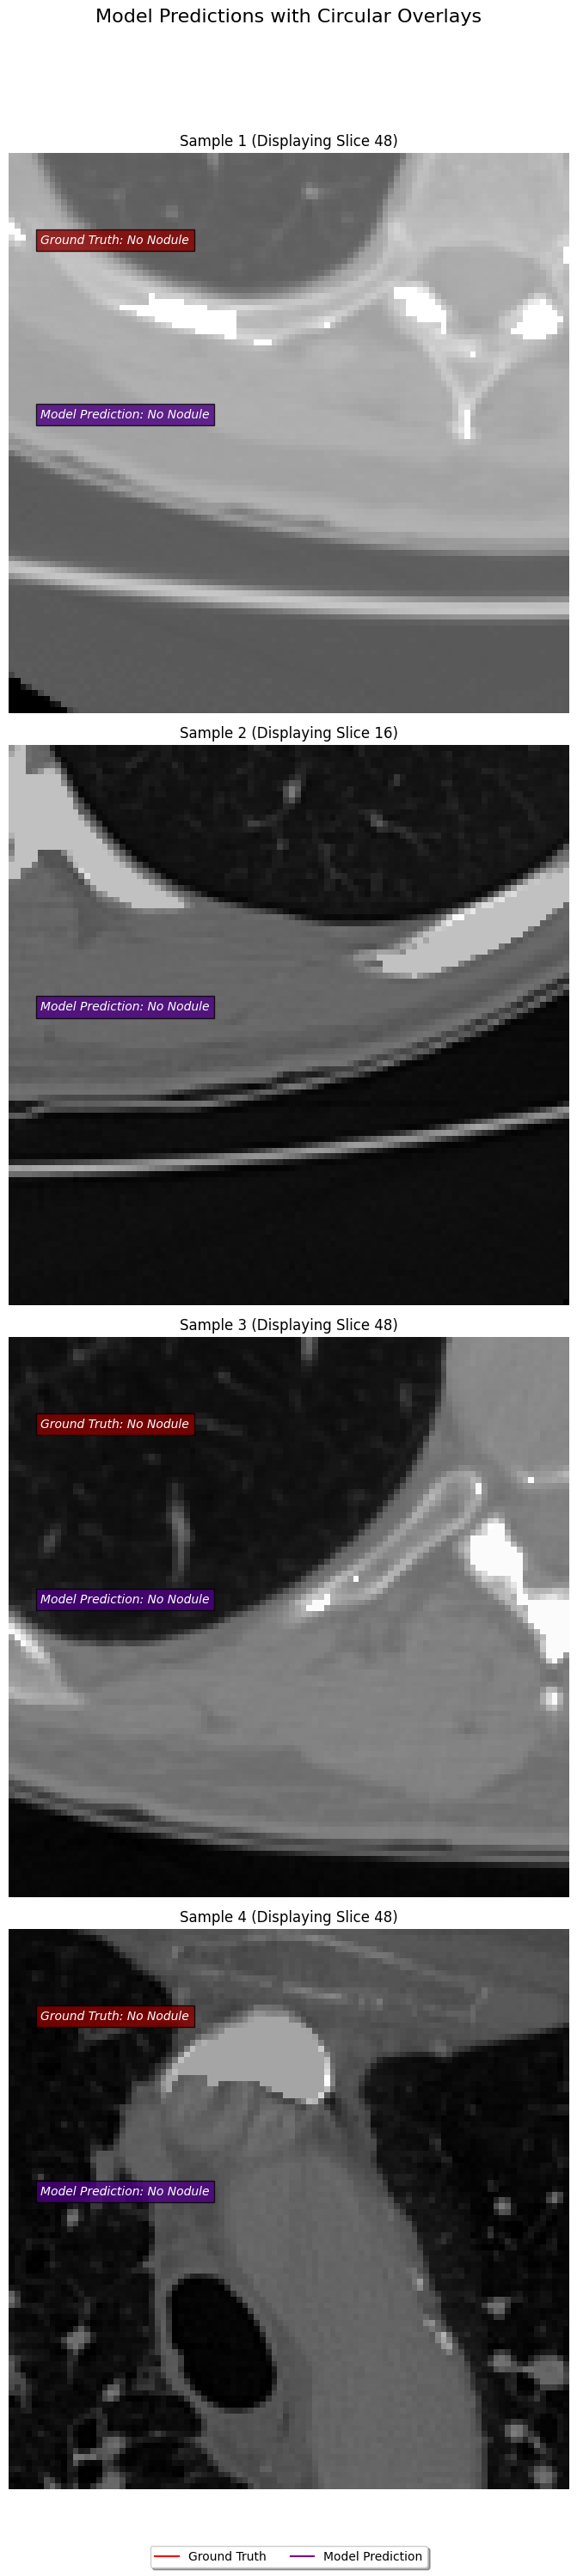

✅ Visualization complete.


In [137]:
import torch
import torch.nn as nn
import numpy as np
import os
import random # For random patch selection if not using fixed test_scan
import matplotlib.pyplot as plt
from matplotlib.patches import Circle # For drawing circles
from torch.utils.data import Dataset, DataLoader # For loading multiple samples
from monai.networks.nets import UNETR
import cv2 # For contour finding

# ===================================================================
# 1. CONFIGURATION
# ===================================================================
# --- Paths and Parameters ---
# !!! IMPORTANT: Update these paths !!!
MODEL_PATH = "unetr_3d_nodule_segmentation01.pth"
# For visualization of multiple samples, it's better to use a dataset structure
# pointing to your preprocessed data and masks directories
DATA_DIR = "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/processed_data_subset1/"
MASKS_DIR = "/content/drive/My Drive/Lung Cancer Project/Preprocessed_subset1/ground_truth_masks_subset1/"

# --- Model Parameters (Must match your training setup) ---
PATCH_SIZE = (96, 96, 96)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4 # Number of samples to display in the visualization

# ===================================================================
# 2. MODEL AND DATASET DEFINITIONS
# ===================================================================

# --- UNETR Model Definition ---
def get_unetr_model(patch_size, device):
    """Initializes the UNETR model with the required parameters."""
    return UNETR(
        in_channels=1,
        out_channels=1,
        img_size=patch_size,
        feature_size=16,
        hidden_size=768,
        mlp_dim=3072,
        num_heads=12,
        norm_name="instance",
    ).to(device)

# --- Dataset Definition (Modified to return random patches) ---
class LungNoduleDataset(Dataset):
    """Dataset class that loads scans and returns random 3D patches."""
    def __init__(self, data_dir, masks_dir, patch_size):
        self.data_dir, self.masks_dir, self.patch_size = data_dir, masks_dir, patch_size
        mask_uids = {f.replace('_nodule_mask.npy', '') for f in os.listdir(masks_dir)}
        scan_files = {f.replace('_processed_lung.npy', '') for f in os.listdir(data_dir)}
        self.available_uids = sorted(list(mask_uids.intersection(scan_files)))
    def __len__(self):
        return len(self.available_uids)
    def __getitem__(self, idx):
        uid = self.available_uids[idx]
        scan_path = os.path.join(self.data_dir, f"{uid}_processed_lung.npy")
        mask_path = os.path.join(self.masks_dir, f"{uid}_nodule_mask.npy")
        scan, mask = np.load(scan_path), np.load(mask_path)
        depth, height, width = scan.shape
        pd, ph, pw = self.patch_size
        # Get a random patch
        z,y,x = random.randint(0,depth-pd), random.randint(0,height-ph), random.randint(0,width-pw)
        scan_patch, mask_patch = scan[z:z+pd,y:y+ph,x:x+pw], mask[z:z+pd,y:y+ph,x:x+pw]
        return torch.from_numpy(scan_patch).unsqueeze(0).float(), torch.from_numpy(mask_patch).unsqueeze(0).float()

# ===================================================================
# 3. HELPER FUNCTIONS (for Visualization)
# ===================================================================

def find_best_slice_for_display(gt_mask_3d, pred_mask_3d):
    """
    Automatically finds the most interesting slice to display.
    Prioritizes slices where GT and prediction exist, then GT only, then center.
    """
    patch_depth = gt_mask_3d.shape[0]

    # Priority 1: Find a slice where GT and prediction both exist
    for s in range(patch_depth):
        if np.sum(gt_mask_3d[s]) > 0 and np.sum(pred_mask_3d[s]) > 0:
            return s, "True Positive Case"

    # Priority 2: Find a slice where only GT exists (False Negative case)
    for s in range(patch_depth):
        if np.sum(gt_mask_3d[s]) > 0:
            return s, "False Negative Case"

    # Default: No GT nodules found in the patch, return the center slice
    return patch_depth // 2, "Negative Patch"

def draw_circular_overlay(ax, mask_slice, color, linewidth=2):
    """Finds contours in a binary mask and draws a minimum enclosing circle."""
    mask_uint8 = (mask_slice * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        if len(cnt) >= 5: # Need at least 5 points to fit a circle
            (x, y), radius = cv2.minEnclosingCircle(cnt)
            if radius > 1: # Only draw meaningful circles
                circle = Circle((x, y), radius, edgecolor=color, facecolor='none', linewidth=linewidth)
                ax.add_patch(circle)

def add_text_notification(ax, text, color, y_pos=15):
    """Adds a formatted text notification to the plot."""
    ax.text(5, y_pos, text, style='italic', color='white', fontsize=10,
            bbox={'facecolor': color, 'alpha': 0.8, 'pad': 4})

# ===================================================================
# 4. MAIN SCRIPT LOGIC
# ===================================================================
if __name__ == '__main__':
    # --- Load Model ---
    print(f"Loading trained model from {MODEL_PATH}...")
    model = get_unetr_model(patch_size=PATCH_SIZE, device=DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))
    model.eval() # Set the model to evaluation mode (very important!)
    print("✅ Model loaded successfully.")

    # --- Load Data Samples ---
    dataset = LungNoduleDataset(DATA_DIR, MASKS_DIR, PATCH_SIZE)
    # Using a DataLoader to easily get a batch of random samples
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    print("✅ Dataset loaded.")

    print("\nGenerating predictions and visualizations...")

    # Get a batch of samples
    images, masks = next(iter(dataloader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)

    with torch.no_grad():
        preds = (torch.sigmoid(model(images)) > 0.5).float()

    # Move all data to CPU and NumPy for plotting
    images_np = images.cpu().numpy()
    masks_np = masks.cpu().numpy()
    preds_np = preds.cpu().numpy()

    # --- Create the Plot for Visualization ---
    num_samples = images_np.shape[0] # Actual number of samples in the batch
    fig, axes = plt.subplots(num_samples, 1, figsize=(8, num_samples * 8))
    fig.suptitle("Model Predictions with Circular Overlays", fontsize=16)

    if num_samples == 1:
        axes = [axes] # Ensure axes is iterable even for a single subplot

    for i in range(num_samples):
        ax = axes[i]

        # Find the best slice within this 3D patch to visualize
        slice_idx, status_text = find_best_slice_for_display(masks_np[i, 0], preds_np[i, 0])

        # Get the chosen 2D slice from the 3D patch
        img_slice = images_np[i, 0, slice_idx, :, :]
        gt_mask_slice = masks_np[i, 0, slice_idx, :, :]
        pred_mask_slice = preds_np[i, 0, slice_idx, :, :]

        ax.imshow(img_slice, cmap='gray')
        ax.set_title(f"Sample {i+1} (Displaying Slice {slice_idx})")
        ax.axis('off')

        # --- Draw Overlays or Add Text Notifications ---

        # Ground Truth (Red)
        if np.sum(gt_mask_slice) > 0:
            draw_circular_overlay(ax, gt_mask_slice, color='red', linewidth=1.5)
        else:
            add_text_notification(ax, "Ground Truth: No Nodule", 'darkred', y_pos=15)

        # Model Prediction (Purple)
        if np.sum(pred_mask_slice) > 0:
            draw_circular_overlay(ax, pred_mask_slice, color='purple', linewidth=1.5)
        else:
            add_text_notification(ax, "Model Prediction: No Nodule", 'indigo', y_pos=45)

    # --- Create Custom Legend ---
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', lw=1.5, label='Ground Truth'),
        Line2D([0], [0], color='purple', lw=1.5, label='Model Prediction')
    ]
    # Place legend below the subplots
    axes[-1].legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.15),
                    fancybox=True, shadow=True, ncol=2)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to make space for suptitle and legend
    plt.show()
    print("✅ Visualization complete.")

In [130]:
!pip install simpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 17.4 MB/s eta 0:00:00
